# Econ 3916 Final Project Checkpoint
## UCI Adult Income Dataset

**Akash Viswanathan**

## 1. Proposal

**Prediction question:** Can we predict whether an individual's annual income exceeds $50,000 using demographic and work-related census features?

**Prediction vs. causation:** This is a prediction task, not a causal analysis. The goal is to estimate whether someone belongs to the >50k or <=50K class based on observed features. A strong predictive relationship does not mean that any variable causes higher income.

**Dataset:** UCI Adult (or Census Income)  
**Source URL:** https://archive.ics.uci.edu/dataset/2/adult

**Dataset stats:**
- Instances: 48,842
- Features: 14
- Target variable: income (>50K vs <=50K)

**Stakeholder:** This analysis would help a workforce development organization decide which clients may be at higher risk of lower income outcomes, so it can target job training and support resources more effectively.

**Why this matters:** Income classification has practical relevance for labor market analysis, workforce planning, and socioeconomic risk screening.

In [35]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

## 2. Load the Data

In [36]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

df = pd.read_csv(
    data_url,
    header=None,
    names=columns,
    na_values="?",
    skipinitialspace=True
)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [37]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

Shape: (32561, 15)

Data types:
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


### Initial interpretation
The dataset contains a mix of numeric and categorical variables, which makes it a good fit for a supervised classification pipeline. The target variable is binary, so this will be a classification problem.

## 3. Data Quality and Missing Data Assessment

In [39]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percents = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percents.round(2)
})

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percent
occupation,1843,5.66
workclass,1836,5.64
native_country,583,1.79


### Missing-data framework (MCAR / MAR / MNAR)

The missing values appear mainly in categorical columns such as `workclass`, `occupation`, and `native_country`. In this dataset, missing values are represented by `?`, which are converted to `NaN` during loading.

I do not think the missingness is MCAR (Missing Completely at Random), because whether a work class or occupation is missing could plausibly depend on employment status, reporting issues, or other observed characteristics. It is more reasonable to treat this as MAR (Missing At Random), where missingness may depend on other observed variables.

**Chosen strategy:** For the checkpoint, I will keep the rows and handle missing values using imputation inside the machine learning pipeline:
- numeric features: median imputation
- categorical features: most-frequent imputation

This is a practical choice because it preserves sample size and avoids dropping many observations.

### Data quality summary

- The dataset has both numeric and categorical predictors.
- Missing values exist in a few categorical columns and are handled through imputation.
- No duplicate-row handling is applied at this stage because the dataset is already commonly used in benchmark form.
- The target variable is already labeled and suitable for binary classification.

## 4. Exploratory Data Analysis

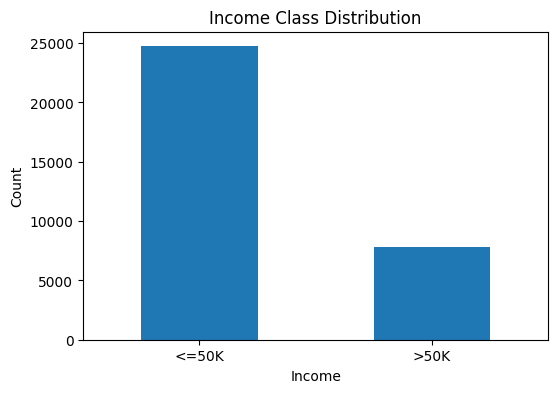

,count
income,
<=50K,24720
>50K,7841


In [40]:
income_counts = df["income"].value_counts()

plt.figure(figsize=(6, 4))
income_counts.plot(kind="bar")
plt.title("Income Class Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

income_counts

**Interpretation:** The target classes are somewhat imbalanced, with more individuals in the `<=50K` category than in the `>50K` category. This matters because a model could appear accurate by overpredicting the majority class, so precision and recall are important metrics in addition to accuracy.

<Figure size 700x400 with 0 Axes>

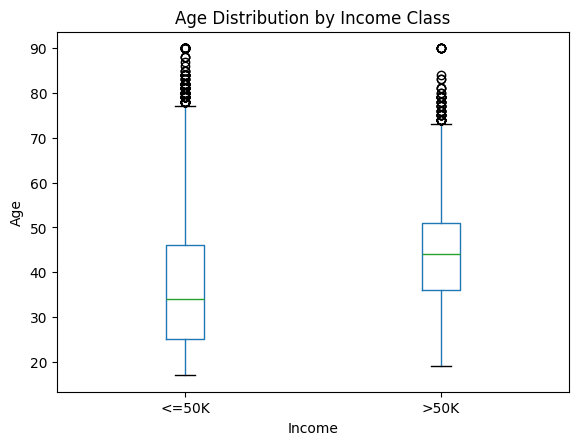

In [41]:
plt.figure(figsize=(7, 4))
df.boxplot(column="age", by="income", grid=False)
plt.title("Age Distribution by Income Class")
plt.suptitle("")
plt.xlabel("Income")
plt.ylabel("Age")
plt.show()

**Interpretation:** Individuals in the >50K group appear older on average than those in the <=50K group. This suggests that age may carry useful predictive signal, possibly reflecting experience or career stage.

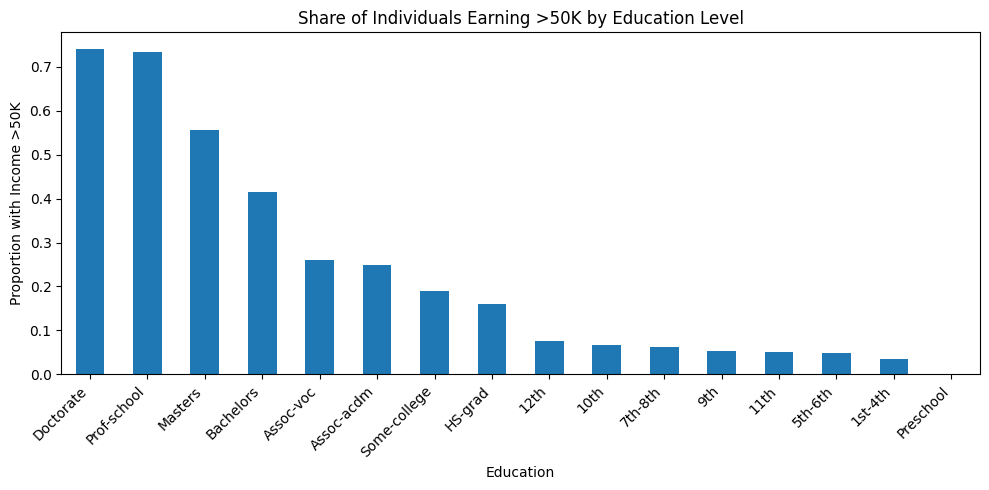

,income
education,
Doctorate,0.740920
Prof-school,0.734375
Masters,0.556587
Bachelors,0.414753
Assoc-voc,0.261216
Assoc-acdm,0.248360
Some-college,0.190235
HS-grad,0.159509
12th,0.076212


In [42]:
edu_income = (
    df.groupby("education")["income"]
    .apply(lambda s: (s == ">50K").mean())
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
edu_income.plot(kind="bar")
plt.title("Share of Individuals Earning >50K by Education Level")
plt.xlabel("Education")
plt.ylabel("Proportion with Income >50K")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

edu_income.head(10)

**Interpretation:** Higher education categories generally have a larger share of individuals earning more than $50K. This does not imply causation, but it does indicate that education level is likely to be an important predictor.

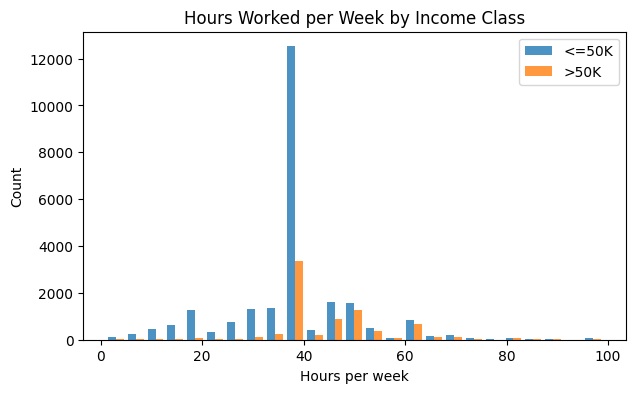

In [43]:
hours_by_income = [
    df.loc[df["income"] == "<=50K", "hours_per_week"].dropna(),
    df.loc[df["income"] == ">50K", "hours_per_week"].dropna()
]

plt.figure(figsize=(7, 4))
plt.hist(hours_by_income, bins=25, label=["<=50K", ">50K"], alpha=0.8)
plt.title("Hours Worked per Week by Income Class")
plt.xlabel("Hours per week")
plt.ylabel("Count")
plt.legend()
plt.show()

**Interpretation:** The >50K group tends to be more concentrated around full-time and above-full-time work hours. This suggests that hours worked per week may also contribute predictive information.

## 5. Prepare Features and Target

In [44]:
X = df.drop(columns="income")
y = df["income"]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:", categorical_features)
print("\nNumeric features:", numeric_features)

Categorical features: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

Numeric features: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']


## 6. Train/Test Split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (26048, 14)
X_test shape: (6513, 14)


## 7. Preliminary Model
### Logistic Regression Pipeline

In [46]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [47]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=">50K")
recall = recall_score(y_test, y_pred, pos_label=">50K")

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

Accuracy:  0.8455
Precision: 0.7244
Recall:    0.5784


In [48]:
cm = confusion_matrix(y_test, y_pred, labels=["<=50K", ">50K"])
cm_df = pd.DataFrame(
    cm,
    index=["Actual <=50K", "Actual >50K"],
    columns=["Predicted <=50K", "Predicted >50K"]
)
cm_df

,Predicted <=50K,Predicted >50K
Actual <=50K,4600,345
Actual >50K,661,907


In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      4945
        >50K       0.72      0.58      0.64      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.75      0.77      6513
weighted avg       0.84      0.85      0.84      6513



### Preliminary model interpretation

The logistic regression model gives a solid baseline for this income classification task, with an overall accuracy of 0.85. Its performance is much stronger for the <=50K group, where it achieves 0.87 precision and 0.93 recall, than for the >50K group, where precision is 0.72 and recall is 0.58. This means the model is fairly good at identifying lower-income cases, but it misses a noticeable portion of people who actually earn more than $50K. Since the classes are imbalanced, accuracy alone does not fully capture performance, so precision and recall are important for understanding where the model does well and where it struggles. Overall, this is a reasonable first benchmark, but the weaker recall for the >50K class suggests there is room for improvement. For the final project, I plan to compare this baseline against a more flexible model, such as a random forest or gradient boosting classifier, to see whether performance on the higher-income class can be improved.